In [3]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import os
import boto3
from dotenv import load_dotenv

%matplotlib inline

In [4]:
header_df_a = pd.DataFrame()
header_df_b = pd.DataFrame()
header_df_c = pd.DataFrame()
header_df_d = pd.DataFrame()
emission_df = pd.DataFrame()


with open('../data/Dataset.csv', 'r') as csv:
    
    rows = csv.readlines()

    header_df_a = pd.DataFrame([row.strip().split(',') for row in rows[13:22]])
    header_df_b = pd.DataFrame([row.strip().split(',') for row in rows[27:31]])
    header_df_c = pd.DataFrame([row.strip().split(',') for row in rows[33:41]])
    header_df_d = pd.DataFrame([row.strip().split(',') for row in rows[43:51]])
    emission_df = pd.read_csv('../data/Dataset.csv', skiprows=52, header=0)

#print(f'DF_A: {header_df_a.head(10)}')
#print(f'\nDF_b: {header_df_b.head(10)}')
#print(f'\nDF_C: {header_df_c.head(10)}')
#print(f'\nDF_D: {header_df_d.head(10)}')

header_concat_df = pd.concat([header_df_a, header_df_b, header_df_c, header_df_d], ignore_index=True)
print(f'DF fmt: {header_concat_df.shape}')

print(emission_df.columns)
print(emission_df.head())

del header_df_a
del header_df_b
del header_df_c
del header_df_d
gc.collect()

DF fmt: (29, 2)
Index(['INDICATION NO.', 'SAMPLE NO.', 'SEQUENCE NO.', 'INDICATION TYPE',
       'EMISSION QUANTIFICATION (SCFH)', 'METHANE AMPLITUDE (PPM)',
       'ETHANE AMPLITUDE (PPB)', 'BACKGROUND METHANE (PPM)',
       'BACKGROUND ETHANE (PPB)', 'LATITUDE (degrees)', 'LONGITUDE (degrees)',
       'INDICATION WIND DIRECTION (degrees)',
       'INDICATION WIND SPEED (miles/hr)', 'VEHICLE DIR (degrees)',
       'VEHICLE SPEED (miles/hr)'],
      dtype='object')
   INDICATION NO.  SAMPLE NO.  SEQUENCE NO.  \
0               1       69006         69026   
1               2       29756         29756   
2               3       74308         74328   
3               4       80327         80347   
4               5       56631         56651   

                           INDICATION TYPE  EMISSION QUANTIFICATION (SCFH)  \
0  High- Confidence Natural Gas Indication                            38.3   
1  High- Confidence Natural Gas Indication                            17.0   
2  High- Conf

585

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

distances = [0] + list(haversine(
    emission_df['LATITUDE (degrees)'][:-1].values,
    emission_df['LONGITUDE (degrees)'][:-1].values,
    emission_df['LATITUDE (degrees)'][1:].values,
    emission_df['LONGITUDE (degrees)'][1:].values,
))

emission_df['Distance_in_miles'] = np.cumsum(distances)

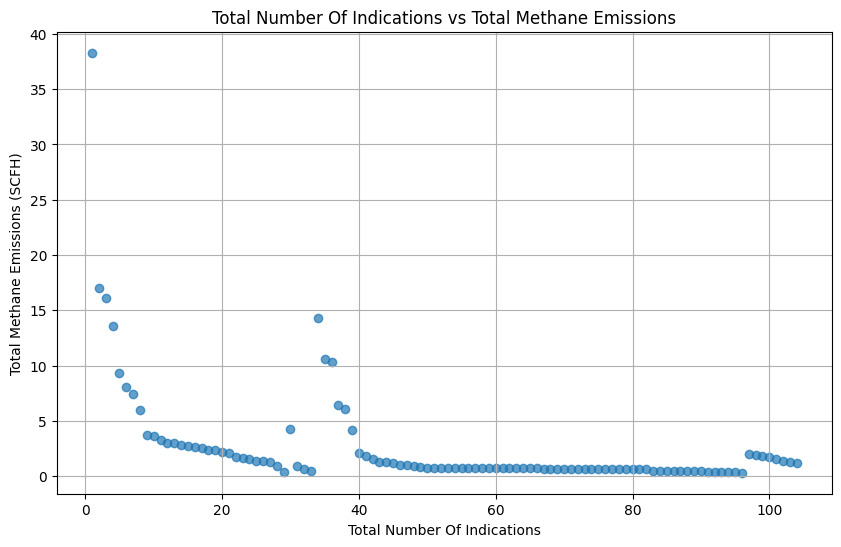

In [4]:
#Total Number Of Indications vs Total Methane Emissions
plt.figure(figsize=(10, 6))
plt.scatter(emission_df['INDICATION NO.'], emission_df['EMISSION QUANTIFICATION (SCFH)'], alpha=0.7)
plt.title('Total Number Of Indications vs Total Methane Emissions')
plt.xlabel('Total Number Of Indications')
plt.ylabel('Total Methane Emissions (SCFH)')
plt.grid(True)
plt.show()

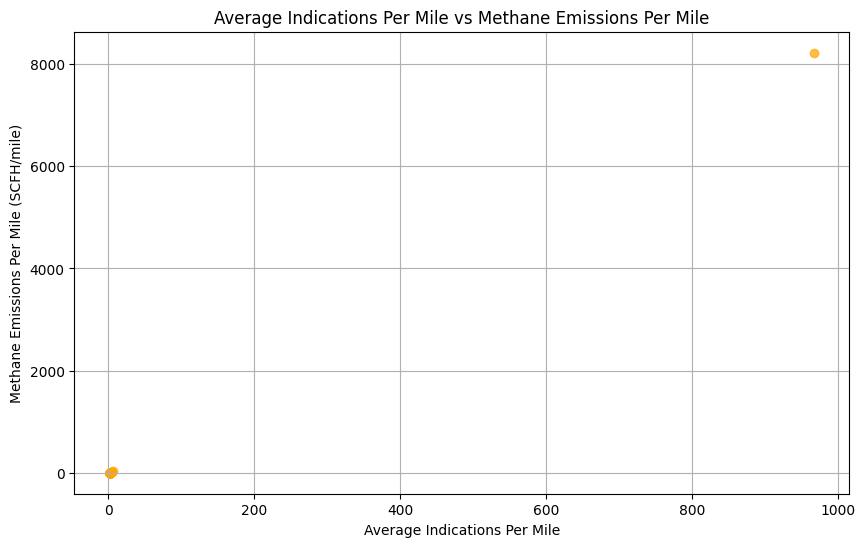

In [10]:
#Average Indications Per Mile vs Methane Emissions Per Mile

emission_df['Average Indications Per Mile'] = emission_df['INDICATION NO.'] / emission_df['Distance_in_miles'].replace(0, np.nan)
emission_df['Methane Emissions Per Mile'] = emission_df['EMISSION QUANTIFICATION (SCFH)'] / emission_df['Distance_in_miles'].replace(0, np.nan)

plt.figure(figsize=(10, 6))
plt.scatter(emission_df['Average Indications Per Mile'], emission_df['Methane Emissions Per Mile'], color='orange', alpha=0.7)
plt.title('Average Indications Per Mile vs Methane Emissions Per Mile')
plt.xlabel('Average Indications Per Mile')
plt.ylabel('Methane Emissions Per Mile (SCFH/mile)')
plt.grid(True)
plt.show()

In [6]:
load_dotenv()

AWS_S3_KEY = os.getenv("AWS_ACCESS_KEY_ID")
AWS_S3_PWD = os.getenv("AWS_SECRET_ACCESS_KEY")
AWS_S3_PATH = os.getenv("AWS_S3_PATH")
 
emissions_header_report = f"{AWS_S3_PATH}emissions_header_report.csv"
emissions_dataframe_report = f"{AWS_S3_PATH}emissions_dataset_report.csv"

header_concat_df.to_csv(emissions_header_report, index=False, storage_options={"key": AWS_S3_KEY, "secret": AWS_S3_PWD})
emission_df.to_csv(emissions_dataframe_report, index=False, storage_options={"key": AWS_S3_KEY, "secret": AWS_S3_PWD})